In [22]:
from datasets import load_dataset
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import transformers
from transformers import pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [2]:
dataset = load_dataset("kofiyo/reviews", split='train[:-1]')

In [3]:
df = pd.DataFrame(dataset)
print(df)

                                                   text
0            1\tThe Da Vinci Code book is just awesome.
1     1\tthis was the first clive cussler i've ever ...
2                   1\ti liked the Da Vinci Code a lot.
3                   1\ti liked the Da Vinci Code a lot.
4     1\tI liked the Da Vinci Code but it ultimatly ...
...                                                 ...
7080  0\tOh, and Brokeback Mountain is a TERRIBLE mo...
7081                  0\tBrokeback Mountain was boring.
7082    0\tSo Brokeback Mountain was really depressing.
7083  0\tAs I sit here, watching the MTV Movie Award...
7084  0\tOk brokeback mountain is such a horrible mo...

[7085 rows x 1 columns]


In [4]:
df['no_punkt_lower'] = df['text'].apply(lambda x: re.sub(r'[^a-zA-Z\s]', "", x.lower()))
print(df['no_punkt_lower'])

0                \tthe da vinci code book is just awesome
1       \tthis was the first clive cussler ive ever re...
2                       \ti liked the da vinci code a lot
3                       \ti liked the da vinci code a lot
4       \ti liked the da vinci code but it ultimatly d...
                              ...                        
7080      \toh and brokeback mountain is a terrible movie
7081                      \tbrokeback mountain was boring
7082        \tso brokeback mountain was really depressing
7083    \tas i sit here watching the mtv movie awards ...
7084     \tok brokeback mountain is such a horrible movie
Name: no_punkt_lower, Length: 7085, dtype: object


In [5]:
df['tokens_lower'] = df['no_punkt_lower'].apply(lambda token: [word for word in word_tokenize(token)])
print(df['tokens_lower'])

0         [the, da, vinci, code, book, is, just, awesome]
1       [this, was, the, first, clive, cussler, ive, e...
2                [i, liked, the, da, vinci, code, a, lot]
3                [i, liked, the, da, vinci, code, a, lot]
4       [i, liked, the, da, vinci, code, but, it, ulti...
                              ...                        
7080    [oh, and, brokeback, mountain, is, a, terrible...
7081                   [brokeback, mountain, was, boring]
7082    [so, brokeback, mountain, was, really, depress...
7083    [as, i, sit, here, watching, the, mtv, movie, ...
7084    [ok, brokeback, mountain, is, such, a, horribl...
Name: tokens_lower, Length: 7085, dtype: object


In [6]:
en_stopwords = stopwords.words('english')

In [7]:
df['stopword_clean'] = df['tokens_lower'].apply(lambda x: [word for word in x if word not in en_stopwords])
print(df['stopword_clean'])

0                        [da, vinci, code, book, awesome]
1       [first, clive, cussler, ive, ever, read, even,...
2                           [liked, da, vinci, code, lot]
3                           [liked, da, vinci, code, lot]
4       [liked, da, vinci, code, ultimatly, didnt, see...
                              ...                        
7080           [oh, brokeback, mountain, terrible, movie]
7081                        [brokeback, mountain, boring]
7082            [brokeback, mountain, really, depressing]
7083    [sit, watching, mtv, movie, awards, reminded, ...
7084           [ok, brokeback, mountain, horrible, movie]
Name: stopword_clean, Length: 7085, dtype: object


In [8]:
ps = PorterStemmer()

In [9]:
df['stemm_tokens'] = df['stopword_clean'].apply(lambda token: [ps.stem(word) for word in token])
print(df['stemm_tokens'])

0                         [da, vinci, code, book, awesom]
1       [first, clive, cussler, ive, ever, read, even,...
2                            [like, da, vinci, code, lot]
3                            [like, da, vinci, code, lot]
4       [like, da, vinci, code, ultimatli, didnt, seem...
                              ...                        
7080             [oh, brokeback, mountain, terribl, movi]
7081                          [brokeback, mountain, bore]
7082               [brokeback, mountain, realli, depress]
7083    [sit, watch, mtv, movi, award, remind, much, d...
7084             [ok, brokeback, mountain, horribl, movi]
Name: stemm_tokens, Length: 7085, dtype: object


In [10]:
lemmatizer = WordNetLemmatizer()

In [11]:
df['lemmatizer_tokens'] = df['stopword_clean'].apply(lambda token: [lemmatizer.lemmatize(word) for word in token])
print(df['lemmatizer_tokens'])

0                        [da, vinci, code, book, awesome]
1       [first, clive, cussler, ive, ever, read, even,...
2                           [liked, da, vinci, code, lot]
3                           [liked, da, vinci, code, lot]
4       [liked, da, vinci, code, ultimatly, didnt, see...
                              ...                        
7080           [oh, brokeback, mountain, terrible, movie]
7081                        [brokeback, mountain, boring]
7082            [brokeback, mountain, really, depressing]
7083    [sit, watching, mtv, movie, award, reminded, m...
7084           [ok, brokeback, mountain, horrible, movie]
Name: lemmatizer_tokens, Length: 7085, dtype: object


In [12]:
df['text_cleaned'] = df['tokens_lower'].apply(lambda token: " ".join(token))
print(df['text_cleaned'])

0                  the da vinci code book is just awesome
1       this was the first clive cussler ive ever read...
2                         i liked the da vinci code a lot
3                         i liked the da vinci code a lot
4       i liked the da vinci code but it ultimatly did...
                              ...                        
7080        oh and brokeback mountain is a terrible movie
7081                        brokeback mountain was boring
7082          so brokeback mountain was really depressing
7083    as i sit here watching the mtv movie awards i ...
7084       ok brokeback mountain is such a horrible movie
Name: text_cleaned, Length: 7085, dtype: object


In [13]:
vader_sentiment = SentimentIntensityAnalyzer()

In [14]:
df['vader_sentance_score'] = df['text_cleaned'].apply(lambda review: vader_sentiment.polarity_scores(review)['compound'])
print(df['vader_sentance_score'])

0       0.6249
1       0.5023
2       0.4215
3       0.4215
4       0.2263
         ...  
7080   -0.4767
7081   -0.3182
7082   -0.4391
7083    0.0772
7084   -0.3182
Name: vader_sentance_score, Length: 7085, dtype: float64


In [15]:
bins = [-1, -0.1, 0.1, 1]
names = ['negative', 'neutral', 'positive']
df['vader_sentance_label'] = pd.cut(df['vader_sentance_score'], bins, labels=names)

<Axes: xlabel='vader_sentance_label'>

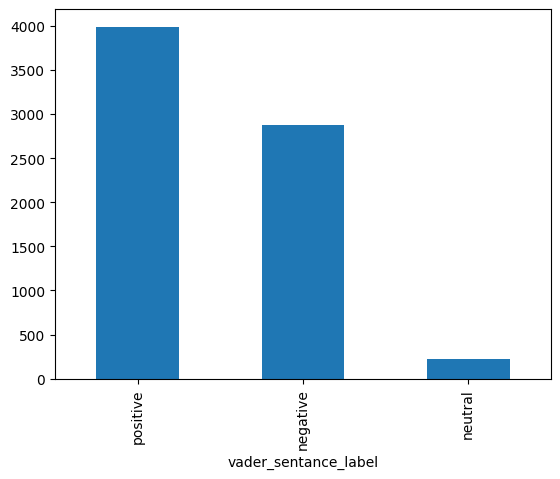

In [16]:
df['vader_sentance_label'].value_counts().plot.bar()

In [17]:
transformer_pipeline = pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use mps:0


In [18]:
transformer_labels =[]
for review in df['text_cleaned'].values:
    sentiment_list = transformer_pipeline(review)
    setiment_label = [sent['label'] for sent in sentiment_list]
    transformer_labels.append(setiment_label)

In [19]:
df["transformer_sentiment_label"] = transformer_labels

<Axes: xlabel='transformer_sentiment_label'>

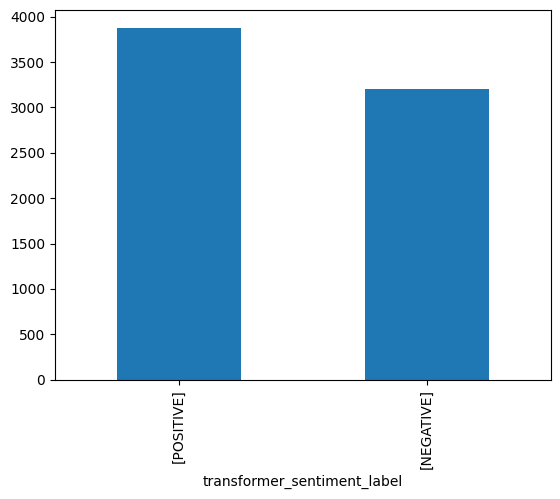

In [20]:
df["transformer_sentiment_label"].value_counts().plot.bar()

In [23]:
coutvec = CountVectorizer()

In [24]:
countvec_fit = coutvec.fit_transform(df['text_cleaned'])

In [25]:
bag_of_words = pd.DataFrame(countvec_fit.toarray(), columns=coutvec.get_feature_names_out())

In [26]:
print(bag_of_words)

      aaron  able  abortion  about  abrams  absolute  absolutely  absurd  \
0         0     0         0      0       0         0           0       0   
1         0     0         0      0       0         0           0       0   
2         0     0         0      0       0         0           0       0   
3         0     0         0      0       0         0           0       0   
4         0     0         0      0       0         0           0       0   
...     ...   ...       ...    ...     ...       ...         ...     ...   
7080      0     0         0      0       0         0           0       0   
7081      0     0         0      0       0         0           0       0   
7082      0     0         0      0       0         0           0       0   
7083      0     0         0      0       0         0           0       0   
7084      0     0         0      0       0         0           0       0   

      academy  acceptable  ...  you  youand  young  younger  your  youre  \
0          

In [27]:
tfidfvec = TfidfVectorizer()

In [28]:
tfidfvec_fit = tfidfvec.fit_transform(df['text_cleaned'])

In [29]:
tfidfvec_words = pd.DataFrame(tfidfvec_fit.toarray(), columns=tfidfvec.get_feature_names_out())

In [30]:
print(tfidfvec_words)

      aaron  able  abortion  about  abrams  absolute  absolutely  absurd  \
0       0.0   0.0       0.0    0.0     0.0       0.0         0.0     0.0   
1       0.0   0.0       0.0    0.0     0.0       0.0         0.0     0.0   
2       0.0   0.0       0.0    0.0     0.0       0.0         0.0     0.0   
3       0.0   0.0       0.0    0.0     0.0       0.0         0.0     0.0   
4       0.0   0.0       0.0    0.0     0.0       0.0         0.0     0.0   
...     ...   ...       ...    ...     ...       ...         ...     ...   
7080    0.0   0.0       0.0    0.0     0.0       0.0         0.0     0.0   
7081    0.0   0.0       0.0    0.0     0.0       0.0         0.0     0.0   
7082    0.0   0.0       0.0    0.0     0.0       0.0         0.0     0.0   
7083    0.0   0.0       0.0    0.0     0.0       0.0         0.0     0.0   
7084    0.0   0.0       0.0    0.0     0.0       0.0         0.0     0.0   

      academy  acceptable  ...  you  youand  young  younger  your  youre  \
0         0